In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from keras.models import load_model
from PIL import Image
import cv2
import os
from PIL import Image
from pathlib import Path


2026-02-23 15:56:06.401220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771862166.599637      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771862166.657201      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.applications import VGG16
#from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
model = Path('/kaggle/input/facial-age/face_age')
age_df = model 

In [4]:
image_data = []


def convert_df(folder_Path):
    for folder_name in os.listdir(folder_Path):
        folder_path = os.path.join(folder_Path, folder_name)
    
        if os.path.isdir(folder_path):  # Check if it is a directory
            for image_name in os.listdir(folder_path):
                if image_name.endswith(('.png', '.jpg', '.jpeg')):  # Filter image types
                    image_path = os.path.join(folder_path, image_name)
                    if folder_Path == age_df:
                        image_data.append({'image_path': image_path, 'label': folder_name})


age_df = convert_df(age_df)
age_df = pd.DataFrame(image_data)


In [5]:
age_df.shape

(9778, 2)

In [6]:
print(age_df.head())

                                       image_path label
0  /kaggle/input/facial-age/face_age/057/6802.png   057
1  /kaggle/input/facial-age/face_age/057/3702.png   057
2  /kaggle/input/facial-age/face_age/057/8810.png   057
3  /kaggle/input/facial-age/face_age/057/6759.png   057
4  /kaggle/input/facial-age/face_age/057/1846.png   057


In [7]:
age_df['label'] = pd.to_numeric(age_df['label'], errors='coerce')

In [8]:
print(age_df['label'].isna().sum())  # Check how many NaNs are present

0


In [9]:
# Specify the bins and labels
bins = [0, 5, 10, 15, 20, 25, 30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]  # Adjust the upper limit as needed
labels = ['1-5', '5-10', '10-15', '15-20', '20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100']  # Adjust as necessary

# Assuming the age information is in a column named 'age'
age_df['label'] = pd.cut(age_df['label'], bins=bins, labels=labels, right=True)

print(age_df['label'].head())


0    55-60
1    55-60
2    55-60
3    55-60
4    55-60
Name: label, dtype: category
Categories (20, object): ['1-5' < '5-10' < '10-15' < '15-20' ... '80-85' < '85-90' < '90-95' < '95-100']


In [10]:
print(age_df.dtypes)

image_path      object
label         category
dtype: object


In [11]:
print()

In [12]:
age_df["label"].value_counts()

label
1-5       2311
25-30      809
5-10       775
20-25      714
15-20      657
10-15      524
35-40      518
30-35      492
50-55      486
55-60      484
45-50      399
60-65      315
40-45      296
65-70      257
70-75      226
80-85      187
75-80      171
85-90      114
90-95       20
95-100      20
Name: count, dtype: int64

In [13]:
print(age_df.head(1000))

                                         image_path  label
0    /kaggle/input/facial-age/face_age/057/6802.png  55-60
1    /kaggle/input/facial-age/face_age/057/3702.png  55-60
2    /kaggle/input/facial-age/face_age/057/8810.png  55-60
3    /kaggle/input/facial-age/face_age/057/6759.png  55-60
4    /kaggle/input/facial-age/face_age/057/1846.png  55-60
..                                              ...    ...
995  /kaggle/input/facial-age/face_age/009/1638.png   5-10
996  /kaggle/input/facial-age/face_age/009/1005.png   5-10
997  /kaggle/input/facial-age/face_age/009/7152.png   5-10
998  /kaggle/input/facial-age/face_age/009/9473.png   5-10
999  /kaggle/input/facial-age/face_age/009/3835.png   5-10

[1000 rows x 2 columns]


In [14]:
def load_and_preprocess_data(age_df, input_width, input_height):
    images = []
    labels = []
    
    for index, row in age_df.iterrows():
        image_path = row['image_path']
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        image = cv2.resize(image, (input_width, input_height))  # Resize
        
        images.append(image)
        labels.append(row['label'])
    
    images = np.array(images) / 255.0  # Normalize images
    images = np.expand_dims(images, axis=-1)  # Add channels dimension
    
    return images, np.array(labels)

In [15]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [16]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # Add L2 regularization
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model




In [17]:
from tensorflow.keras.layers import Dropout

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))  # Add dropout after the first pooling layer

    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))  # Add dropout after the second pooling layer

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Add dropout before the output layer
    model.add(Dense(num_classes, activation='softmax'))  # Output layer for classification
    return model


In [18]:
input_width, input_height = 200, 200  # Modify as needed
images, labels = load_and_preprocess_data(age_df, input_width, input_height)

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(images, labels_categorical, test_size=0.2, random_state=42)

# Build the model
model = create_model((input_width, input_height, 1), len(le.classes_))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1)




# Train the model
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[early_stop])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771862250.611295      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1771862257.347070      99 service.cc:148] XLA service 0x7a371000ca00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771862257.347940      99 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771862257.633191      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


  7/245 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0452 - loss: 7.4453

I0000 00:00:1771862261.787177      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.2125 - loss: 3.2599 - val_accuracy: 0.2526 - val_loss: 2.3718
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.2798 - loss: 2.3402 - val_accuracy: 0.3078 - val_loss: 2.1299
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3159 - loss: 2.1002 - val_accuracy: 0.3298 - val_loss: 2.0336
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3410 - loss: 2.0098 - val_accuracy: 0.3584 - val_loss: 1.9529
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3596 - loss: 1.9135 - val_accuracy: 0.3620 - val_loss: 1.8896
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3844 - loss: 1.8420 - val_accuracy: 0.3845 - val_loss: 1.8176
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4082 - loss: 1.7653 - val_accuracy: 0.3860 - val_loss: 1.8213
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3971 - loss: 1.7591 - val_accuracy: 0.40

In [19]:
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy:.2f}')

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4153 - loss: 1.8120
Validation Accuracy: 0.41


In [20]:
model.save('age-model.h5')

In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder


In [27]:
# Load your trained model
model_path = '/kaggle/working/age-model.h5'  # Path to your .h5 model
model = load_model(model_path)

labels = ['1-5', '5-10', '10-15', '15-20', '20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100']  # Adjust as necessary


#labels = ['ahegao', 'angry', 'happy', 'neutral', 'sad', 'surprise']
le = LabelEncoder()
le.fit(labels)

LabelEncoder()

In [23]:
import cv2


In [28]:
def preprocess_image(image_path, input_width, input_height):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    image = cv2.resize(image, (input_width, input_height))  # Resize

    # Normalize the image
    image = image / 255.0  # Scale pixel values to [0, 1]
    
    # Add channel dimension and batch dimension
    image = np.expand_dims(image, axis=-1)  # Shape: (height, width, 1)
    image = np.expand_dims(image, axis=0)   # Shape: (1, height, width, 1)
    
    return image


In [29]:
print(le.classes_)

['1-5' '10-15' '15-20' '20-25' '25-30' '30-35' '35-40' '40-45' '45-50'
 '5-10' '50-55' '55-60' '60-65' '65-70' '70-75' '75-80' '80-85' '85-90'
 '90-95' '95-100']


In [51]:
def predict_age_on_image(model, image_path, input_width, input_height):
    processed_image = preprocess_image(image_path, input_width, input_height)
    
    # Make prediction
    predictions = model.predict(processed_image)
    # Get the predicted class index
    predicted_class_index = np.argmax(predictions[0])
    
    return le.inverse_transform([predicted_class_index])[0]  # Convert back to label

# Example usage with a list of test images
test_images = ['/kaggle/input/datasets/alifshahariar/utkface-dataset-face-aligned-and-labeled/utkface-aligned-labeled/images/100_1_2_20170112213615815.jpg.chip.jpg']  # Update with actual paths
input_width, input_height = 200, 200  # Ensure these match your model input dimensions

predictions = {}
for img in test_images:
    predicted_age = predict_age_on_image(model, img, input_width, input_height)
    predictions[img] = predicted_age

# Display results
for img_path, age in predictions.items():
    print(f'Image: {img_path} - Predicted age: {age}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Image: /kaggle/input/datasets/alifshahariar/utkface-dataset-face-aligned-and-labeled/utkface-aligned-labeled/images/100_1_2_20170112213615815.jpg.chip.jpg - Predicted age: 75-80


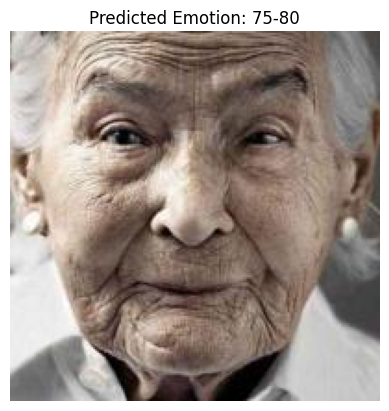

In [54]:
for img_path, emotion in predictions.items():
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
    plt.imshow(img)
    plt.title(f'Predicted Emotion: {emotion}')
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


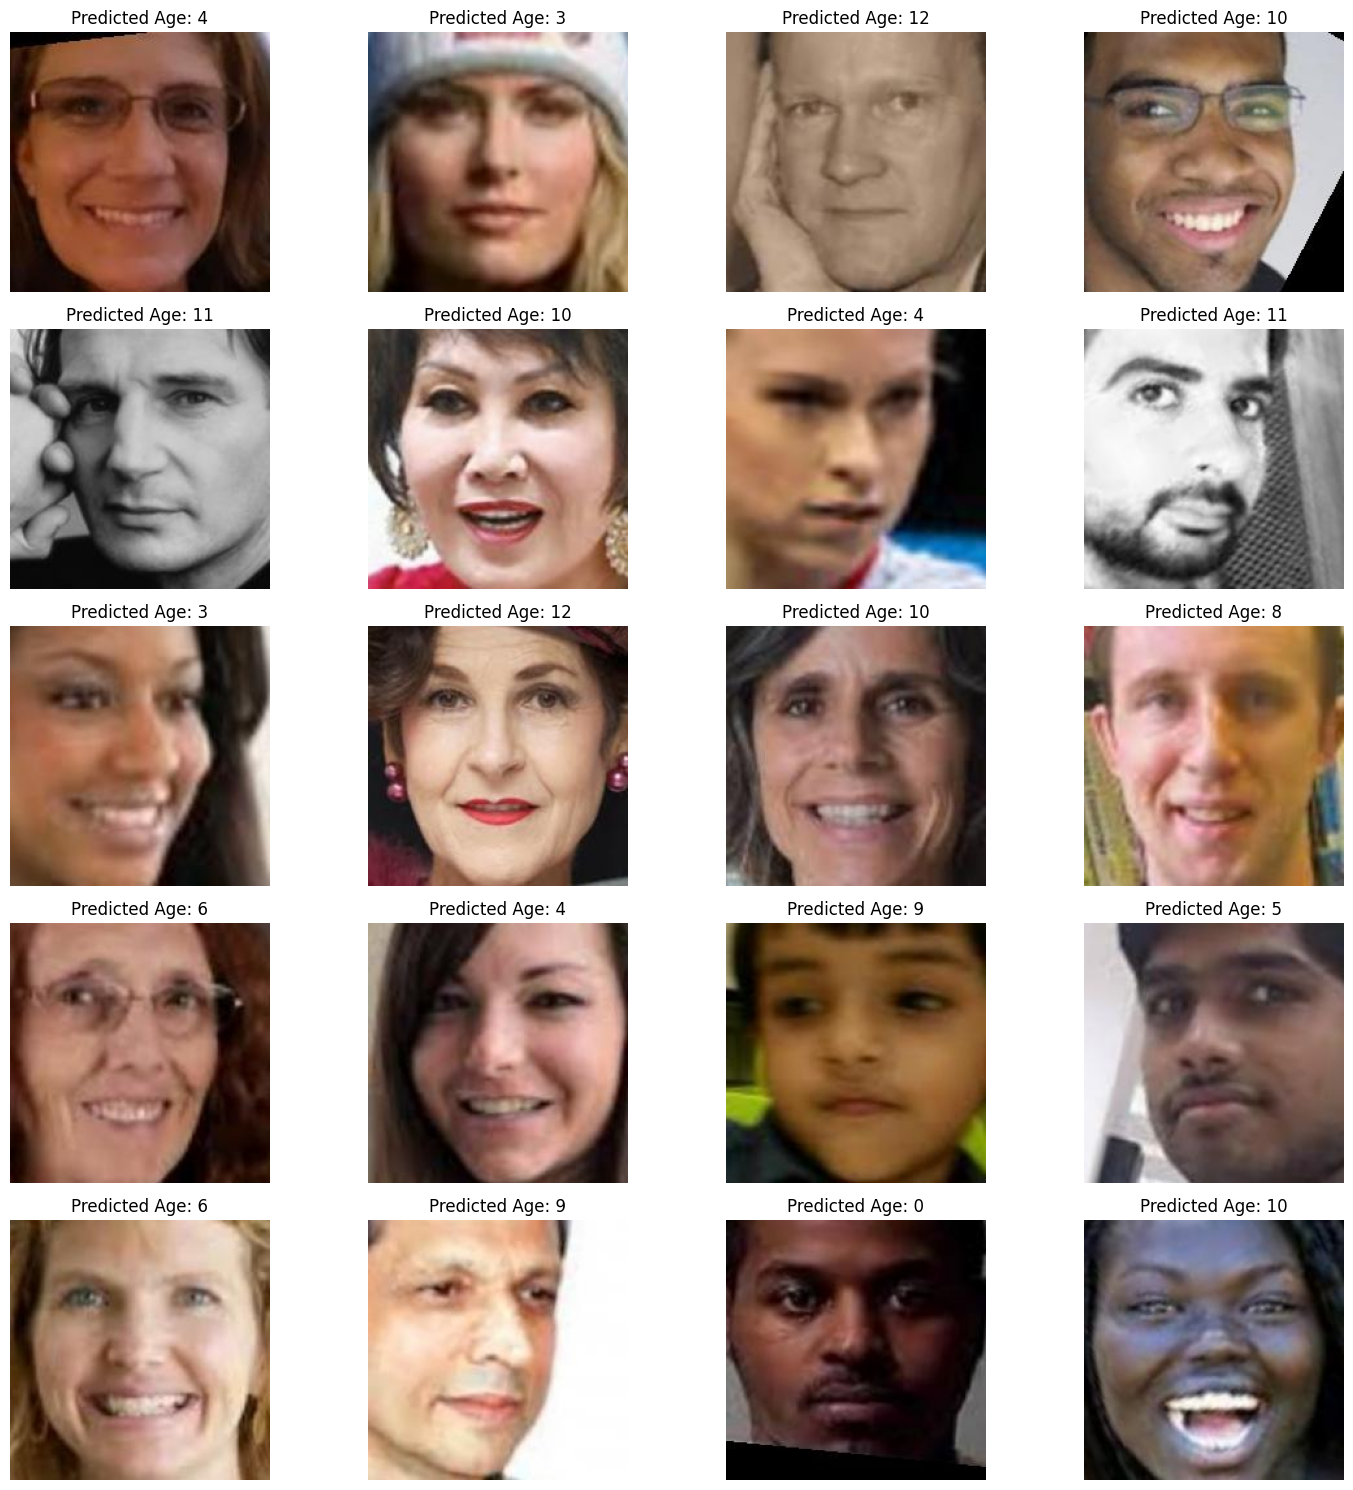

In [62]:
import os
import random
import numpy as np
import cv2
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load the model (replace with your model path)
model = load_model('/kaggle/working/age-model.h5')

# Define the input size of the model (200x200)
img_size = (200, 200)

# Define the UTKFace dataset directory
utkface_dir = "/kaggle/input/datasets/alifshahariar/utkface-dataset-face-aligned-and-labeled/utkface-aligned-labeled/images"  # Update with your dataset path

# List all image files in the dataset directory
all_images = [f for f in os.listdir(utkface_dir) if f.endswith('.jpg')]

# Select 20 random images
random_images = random.sample(all_images, 20)

# Prepare a function to process and predict on the images
def load_and_preprocess_image(img_path, target_size=img_size):
    # Load the image with OpenCV
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale (1 channel)
    img = cv2.resize(img, target_size)  # Resize the image to match the model input size
    img = img.astype('float32') / 255.0  # Normalize pixel values to [0, 1]
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (grayscale, 1 channel)
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Prepare to display the results
plt.figure(figsize=(15, 15))

# Loop over the random images and display results
for idx, img_name in enumerate(random_images):
    img_path = os.path.join(utkface_dir, img_name)
    
    # Preprocess image
    img = load_and_preprocess_image(img_path)

    # Predict the class for the image
    pred = model.predict(img)
    
    # Assuming the model is predicting age (adjust depending on your model's output)
    predicted_age = int(np.argmax(pred))  # If it's a classification problem
    # predicted_age = pred  # If it's a regression problem and returns a continuous value

    # Display the image and prediction
    plt.subplot(5, 4, idx + 1)  # Grid of 5 rows and 4 columns
    img_display = cv2.imread(img_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)  # Convert to RGB for displaying
    plt.imshow(img_display)
    plt.title(f"Predicted Age: {predicted_age}")  # Change this if you have gender/ethnicity prediction
    plt.axis('off')

# Show the plot with images and predictions
plt.tight_layout()
plt.show()

In [53]:
import matplotlib.pyplot as plt


In [55]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,896,023 (72.08 MB)

 Trainable params: 18,896,021 (72.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)